# 03 - Model Prototyping and Backtest from Processed Files
This notebook loads model-ready processed data from data/processed and runs walk-forward modeling plus portfolio diagnostics.

In [1]:
from pathlib import Path
import logging
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.backtester import (
    apply_risk_constraints,
    assign_portfolio_weights,
    compute_daily_strategy_returns_realistic,
    summarize_performance,
)
from src.config import get_settings
from src.dashboard import build_concise_dashboard
from src.experiment_tracking import log_mlflow_run
from src.logging_utils import configure_logging
from src.models_ml import ModelSpec, ValidationSpec, walk_forward_predictions

configure_logging(logging.INFO)
logger = logging.getLogger("notebook.03_model_prototyping")
logger.info("Notebook initialization complete.")

2026-04-02 18:07:27,147 | INFO | notebook.03_model_prototyping | Notebook initialization complete.


In [2]:
logger.info("Step 1/5: Loading model-ready processed dataset from data/processed.")
settings = get_settings()

processed_dir = PROJECT_ROOT / "data" / "processed"
processed_parquet_path = processed_dir / "model_dataset.parquet"
processed_csv_path = processed_dir / "model_dataset.csv"

dataset = None
source_path = None
if processed_parquet_path.exists():
    try:
        dataset = pd.read_parquet(processed_parquet_path)
        source_path = processed_parquet_path
    except ImportError:
        logger.warning("Parquet engine not available; falling back to CSV processed data.")

if dataset is None and processed_csv_path.exists():
    dataset = pd.read_csv(processed_csv_path)
    source_path = processed_csv_path

if dataset is None:
    raise FileNotFoundError(
        f"Processed dataset not found. Expected one of: {processed_parquet_path} or {processed_csv_path}. "
        "Run notebook 02 first."
    )

logger.info("Loaded processed dataset rows: %d from %s", len(dataset), source_path)
print("Processed source:", source_path)
print('Model dataset rows:', len(dataset))

2026-04-02 18:07:27,304 | INFO | notebook.03_model_prototyping | Step 1/5: Loading model-ready processed dataset from data/processed.
2026-04-02 18:07:27,391 | INFO | notebook.03_model_prototyping | Loaded processed dataset rows: 13695 from c:\Users\kenne\OneDrive\Desktop\Quant_Projects_2026\Cross-Sectional-Machine-Learning-Alpha-for-Equities\data\processed\model_dataset.csv


Processed source: c:\Users\kenne\OneDrive\Desktop\Quant_Projects_2026\Cross-Sectional-Machine-Learning-Alpha-for-Equities\data\processed\model_dataset.csv
Model dataset rows: 13695


In [3]:
logger.info("Step 4/5: Training walk-forward model and generating OOS predictions.")
spec = ModelSpec(name='random_forest', random_state=settings.random_state)
validation = ValidationSpec(n_splits=5, purge_days=5, embargo_days=2, min_train_dates=120)

pred_df = walk_forward_predictions(dataset, spec=spec, validation=validation)
logger.info("Predictions generated: %d rows.", len(pred_df))
print('Out-of-sample predictions:', len(pred_df))
pred_df.head()

2026-04-02 18:07:27,679 | INFO | notebook.03_model_prototyping | Step 4/5: Training walk-forward model and generating OOS predictions.
2026-04-02 18:07:27,788 | INFO | src.models_ml | Running walk-forward predictions with 13695 rows, 2739 unique dates, 5 splits, purge=5, embargo=2.
2026-04-02 18:07:27,797 | INFO | src.models_ml | Fold 1: training rows=2270, test rows=2280.
2026-04-02 18:07:27,801 | INFO | src.models_ml | Building model 'random_forest' with random_state=42.
2026-04-02 18:07:28,918 | INFO | src.models_ml | Fold 2: training rows=4550, test rows=2280.
2026-04-02 18:07:28,919 | INFO | src.models_ml | Building model 'random_forest' with random_state=42.
2026-04-02 18:07:30,255 | INFO | src.models_ml | Fold 3: training rows=6830, test rows=2280.
2026-04-02 18:07:30,256 | INFO | src.models_ml | Building model 'random_forest' with random_state=42.
2026-04-02 18:07:32,102 | INFO | src.models_ml | Fold 4: training rows=9110, test rows=2280.
2026-04-02 18:07:32,105 | INFO | src.mo

Out-of-sample predictions: 11400


,date,ticker,target_fwd_return,prediction
0,2016-11-28,AAPL,-0.022049,0.011993
1,2016-11-28,AMZN,-0.009664,0.002789
2,2016-11-28,GOOGL,-0.009634,0.009063
3,2016-11-28,MSFT,-0.006435,0.002786
4,2016-11-28,NVDA,-0.023696,0.018130


In [4]:
logger.info("Step 5/5: Converting predictions to risk-constrained, realistic net returns.")
weighted_raw = assign_portfolio_weights(pred_df, quantile=settings.top_bottom_quantile)
weighted = apply_risk_constraints(weighted_raw, max_abs_weight=0.25, max_gross_leverage=1.0)

daily = compute_daily_strategy_returns_realistic(
    weighted,
    transaction_cost_bps=5.0,
    slippage_bps=2.0,
)
perf = summarize_performance(daily[['date', 'strategy_return']])
logger.info("Performance dictionary computed successfully.")
perf

2026-04-02 18:07:36,550 | INFO | notebook.03_model_prototyping | Step 5/5: Converting predictions to risk-constrained, realistic net returns.
2026-04-02 18:07:36,611 | INFO | src.backtester | Assigned portfolio weights for 11400 rows across 2280 dates.
2026-04-02 18:07:36,640 | INFO | src.backtester | Applied risk constraints (max_abs_weight=0.250, max_gross_leverage=1.000).
2026-04-02 18:07:36,698 | INFO | src.backtester | Computed realistic daily returns with tc_bps=5.00 and slippage_bps=2.00.
2026-04-02 18:07:36,704 | INFO | src.backtester | Performance summary computed: annual_return=0.0856, sharpe=0.4130, max_drawdown=-0.6377.
2026-04-02 18:07:36,705 | INFO | notebook.03_model_prototyping | Performance dictionary computed successfully.


{'annual_return': 0.08564202886698016,
 'annual_volatility': 0.2073578586512881,
 'sharpe': 0.4130155925799929,
 'max_drawdown': -0.6377457636334369,
 'hit_rate': 0.518859649122807}

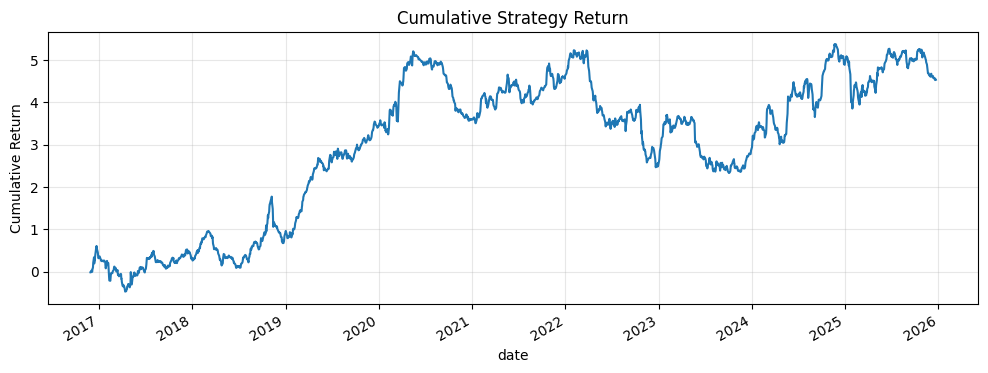

In [43]:
fig, ax = plt.subplots(figsize=(12, 4))
daily.set_index('date')['strategy_return'].cumsum().plot(ax=ax, title='Cumulative Strategy Return')
ax.set_ylabel('Cumulative Return')
ax.grid(alpha=0.3)
plt.show()

2026-04-02 17:41:31,712 | INFO | notebook.03_model_prototyping | Rendering extended diagnostics: drawdown, rolling Sharpe, return distribution, and cross-sectional signal quality.


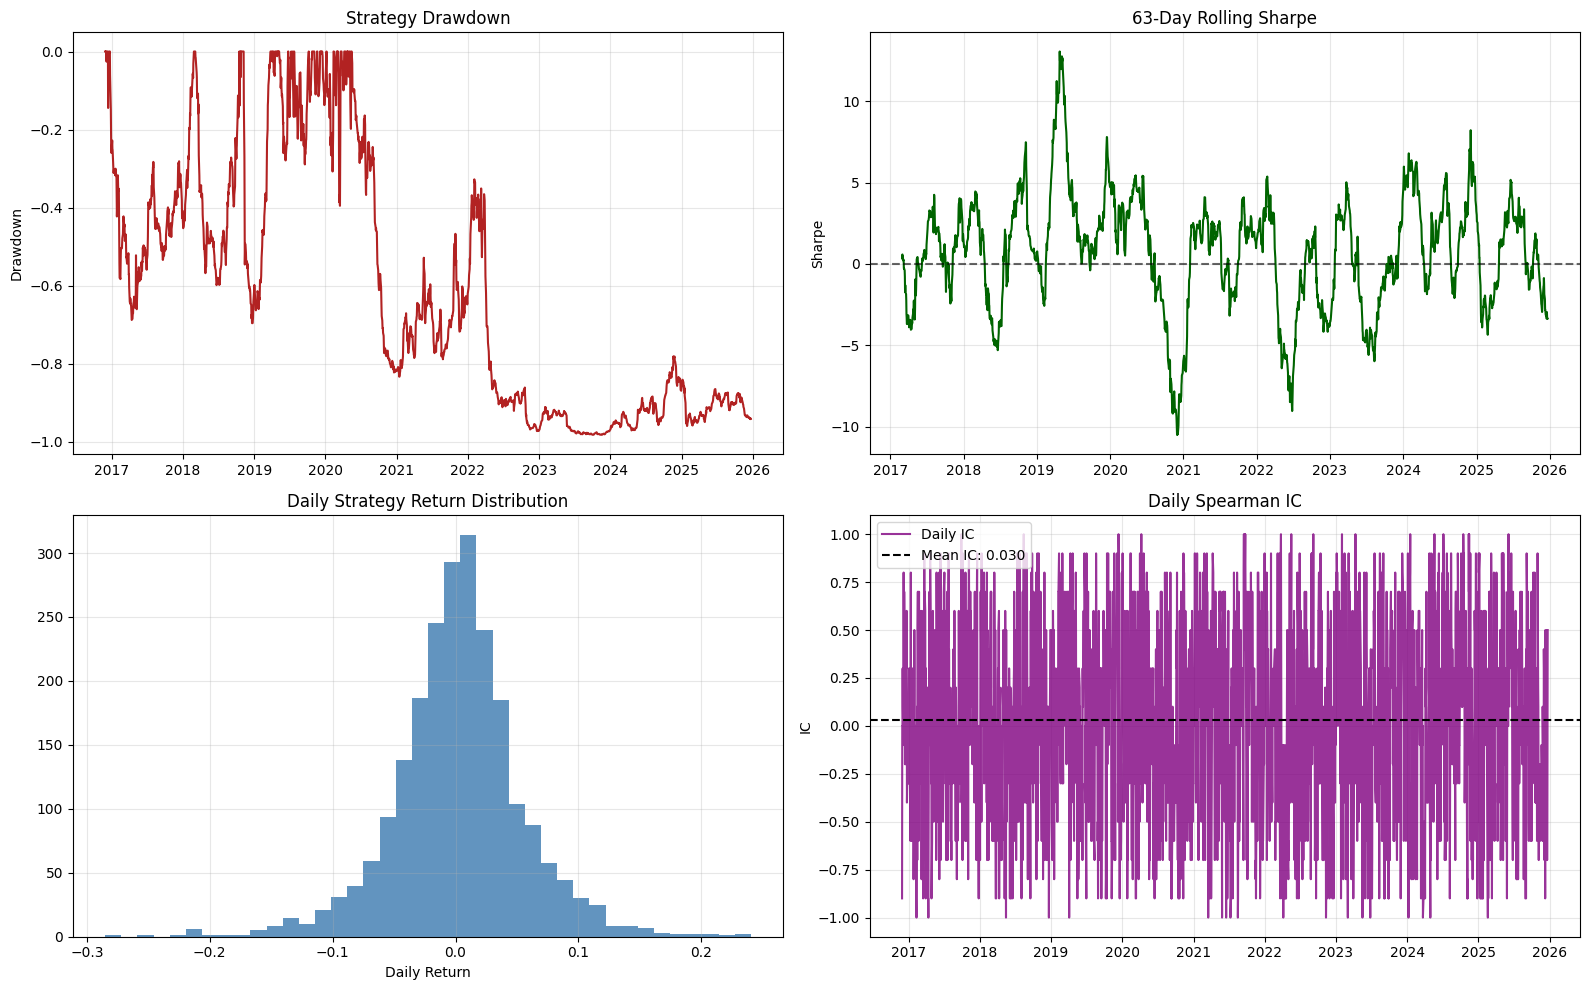

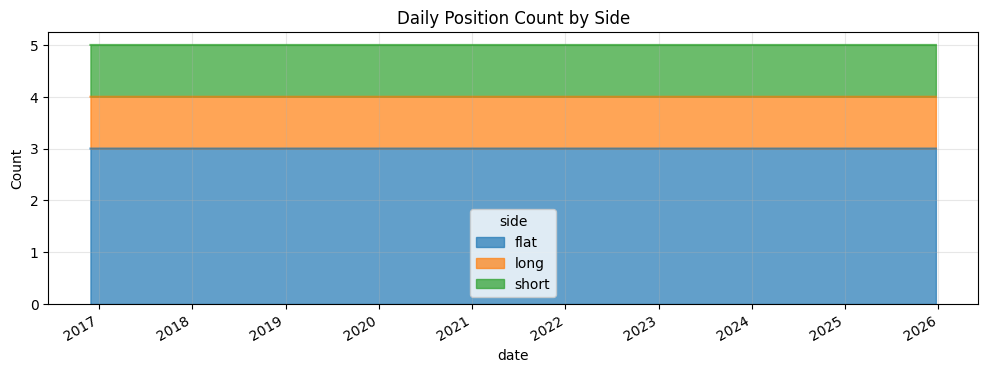

In [44]:
logger.info("Rendering extended diagnostics: drawdown, rolling Sharpe, return distribution, and cross-sectional signal quality.")

daily_plot = daily.copy()
daily_plot['date'] = pd.to_datetime(daily_plot['date'])
daily_plot = daily_plot.sort_values('date').reset_index(drop=True)

equity = (1.0 + daily_plot['strategy_return']).cumprod()
running_peak = equity.cummax()
drawdown = (equity / running_peak) - 1.0

rolling_mean = daily_plot['strategy_return'].rolling(63).mean()
rolling_std = daily_plot['strategy_return'].rolling(63).std(ddof=1)
rolling_sharpe = (rolling_mean / rolling_std) * (252 ** 0.5)

pred_plot = pred_df.copy()
pred_plot['date'] = pd.to_datetime(pred_plot['date'])
ic_by_day = pred_plot.groupby('date').apply(
    lambda g: g['prediction'].corr(g['target_fwd_return'], method='spearman'),
    include_groups=False,
).rename('ic').dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(daily_plot['date'], drawdown, color='firebrick')
axes[0, 0].set_title('Strategy Drawdown')
axes[0, 0].set_ylabel('Drawdown')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(daily_plot['date'], rolling_sharpe, color='darkgreen')
axes[0, 1].axhline(0.0, linestyle='--', color='black', alpha=0.6)
axes[0, 1].set_title('63-Day Rolling Sharpe')
axes[0, 1].set_ylabel('Sharpe')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(daily_plot['strategy_return'], bins=40, color='steelblue', alpha=0.85)
axes[1, 0].set_title('Daily Net Return Distribution')
axes[1, 0].set_xlabel('Daily Return')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(ic_by_day.index, ic_by_day.values, color='purple', alpha=0.8, label='Daily IC')
axes[1, 1].axhline(ic_by_day.mean(), color='black', linestyle='--', label=f"Mean IC: {ic_by_day.mean():.3f}")
axes[1, 1].set_title('Daily Spearman IC')
axes[1, 1].set_ylabel('IC')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

long_short_counts = (
    weighted.groupby(['date', 'side']).size().unstack(fill_value=0).sort_index()
    if not weighted.empty else pd.DataFrame()
)
if not long_short_counts.empty:
    long_short_counts.index = pd.to_datetime(long_short_counts.index)
    ax = long_short_counts.plot(kind='area', stacked=True, figsize=(12, 4), alpha=0.7)
    ax.set_title('Daily Position Count by Side')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)
    plt.show()

In [5]:
from pathlib import Path

output_dir = PROJECT_ROOT / "docs" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

# 1) Cumulative return
fig, ax = plt.subplots(figsize=(12, 4))
daily.set_index('date')['strategy_return'].cumsum().plot(ax=ax, title='Cumulative Strategy Return (Net)')
ax.set_ylabel('Cumulative Return')
ax.grid(alpha=0.3)
cum_path = output_dir / "cumulative_strategy_return.png"
fig.savefig(cum_path, dpi=180, bbox_inches="tight")
plt.close(fig)

# 2) 2x2 diagnostics
daily_plot = daily.copy()
daily_plot['date'] = pd.to_datetime(daily_plot['date'])
daily_plot = daily_plot.sort_values('date').reset_index(drop=True)

equity = (1.0 + daily_plot['strategy_return']).cumprod()
running_peak = equity.cummax()
drawdown = (equity / running_peak) - 1.0

rolling_mean = daily_plot['strategy_return'].rolling(63).mean()
rolling_std = daily_plot['strategy_return'].rolling(63).std(ddof=1)
rolling_sharpe = (rolling_mean / rolling_std) * (252 ** 0.5)

pred_plot = pred_df.copy()
pred_plot['date'] = pd.to_datetime(pred_plot['date'])
ic_by_day = pred_plot.groupby('date').apply(
    lambda g: g['prediction'].corr(g['target_fwd_return'], method='spearman'),
    include_groups=False,
).rename('ic').dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(daily_plot['date'], drawdown, color='firebrick')
axes[0, 0].set_title('Strategy Drawdown')
axes[0, 0].set_ylabel('Drawdown')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(daily_plot['date'], rolling_sharpe, color='darkgreen')
axes[0, 1].axhline(0.0, linestyle='--', color='black', alpha=0.6)
axes[0, 1].set_title('63-Day Rolling Sharpe')
axes[0, 1].set_ylabel('Sharpe')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(daily_plot['strategy_return'], bins=40, color='steelblue', alpha=0.85)
axes[1, 0].set_title('Daily Net Return Distribution')
axes[1, 0].set_xlabel('Daily Return')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(ic_by_day.index, ic_by_day.values, color='purple', alpha=0.8, label='Daily IC')
axes[1, 1].axhline(ic_by_day.mean(), color='black', linestyle='--', label=f"Mean IC: {ic_by_day.mean():.3f}")
axes[1, 1].set_title('Daily Spearman IC')
axes[1, 1].set_ylabel('IC')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
plt.tight_layout()
diag_path = output_dir / "diagnostics_grid.png"
fig.savefig(diag_path, dpi=180, bbox_inches="tight")
plt.close(fig)

# 3) Daily position counts by side
long_short_counts = weighted.groupby(['date', 'side']).size().unstack(fill_value=0).sort_index()
long_short_counts.index = pd.to_datetime(long_short_counts.index)
ax = long_short_counts.plot(kind='area', stacked=True, figsize=(12, 4), alpha=0.7, title='Daily Position Count by Side')
ax.set_ylabel('Count')
ax.grid(alpha=0.3)
fig = ax.get_figure()
pos_path = output_dir / "position_count_by_side.png"
fig.savefig(pos_path, dpi=180, bbox_inches="tight")
plt.close(fig)

# 4) Concise dashboard
dash_path = output_dir / "concise_dashboard.png"
_ = build_concise_dashboard(
    daily_returns=daily[['date', 'strategy_return']],
    perf=perf,
    ic_by_day=ic_by_day,
    output_path=dash_path,
)
plt.close('all')

# 5) MLflow tracking
params = {
    'model_name': spec.name,
    'random_state': spec.random_state,
    'n_splits': validation.n_splits,
    'purge_days': validation.purge_days,
    'embargo_days': validation.embargo_days,
    'quantile': settings.top_bottom_quantile,
    'transaction_cost_bps': 5.0,
    'slippage_bps': 2.0,
}
run_logged = log_mlflow_run(
    experiment_name='cross_sectional_alpha',
    run_name='rf_walkforward_research_grade',
    params=params,
    metrics=perf,
    artifact_paths=[cum_path, diag_path, pos_path, dash_path],
)
print('MLflow run logged:', run_logged)

print("Saved figures to:", output_dir)
sorted([p.name for p in output_dir.glob("*.png")])

2026-04-02 18:07:41,545 | WARNING | src.experiment_tracking | MLflow is not available; skipping experiment tracking.


MLflow run logged: False
Saved figures to: c:\Users\kenne\OneDrive\Desktop\Quant_Projects_2026\Cross-Sectional-Machine-Learning-Alpha-for-Equities\docs\figures


['concise_dashboard.png',
 'cumulative_strategy_return.png',
 'diagnostics_grid.png',
 'position_count_by_side.png']